# Watching a neural net learn to read digits (MNIST)

In the micrograd lectures we built everything out of scalar `Value` objects: a neuron computed `sum(wi*xi) + b`, squashed it with `tanh`, and `backward()` pushed gradients back with the chain rule.

Now we do **exactly the same thing**, just with whole matrices at once, on a real dataset: **MNIST**, 70,000 handwritten digits (28x28 grayscale). The network has to say which digit it is. MNIST has **10 classes: the digits 0 through 9**.

We'll look inside the network the way Andrej Karpathy does in *makemore* and CS231n:

1. **Initialization**: what loss should we expect at step 0, and what goes wrong with a careless init (saturated `tanh`, dead gradients)
2. **Backprop by hand**, checked against numerical gradients (just like the `h = 0.0001` trick in micrograd)
3. **Training** while recording everything
4. **Loss curve**: raw, log scale, smoothed, train vs validation
5. **How the weights and biases change**: histograms, single-parameter trajectories, update:data ratio
6. **What the network sees**: first-layer weights as images, what excites each neuron, linear class templates, saliency maps
7. **Evaluation**: accuracy, predictions, mistakes, confusion matrix

In [1]:
import os
import math
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# consistent colors for the whole lecture
BLUE, ORANGE, AQUA, VIOLET = '#2a78d6', '#eb6834', '#1baf7a', '#4a3aa7'

np.random.seed(42)

## 1. The data

In [2]:
# download MNIST once (~11 MB) and cache it next to the notebook
url = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
path = 'mnist.npz'
if not os.path.exists(path):
  print('downloading MNIST...')
  urllib.request.urlretrieve(url, path)

with np.load(path) as d:
  x_train, y_train = d['x_train'], d['y_train']
  x_test, y_test = d['x_test'], d['y_test']

print('train images:', x_train.shape, 'labels:', y_train.shape)
print('test  images:', x_test.shape, 'labels:', y_test.shape)
print('pixel values from', x_train.min(), 'to', x_train.max())

train images: (60000, 28, 28) labels: (60000,)
test  images: (10000, 28, 28) labels: (10000,)
pixel values from 0 to 255


label: 5


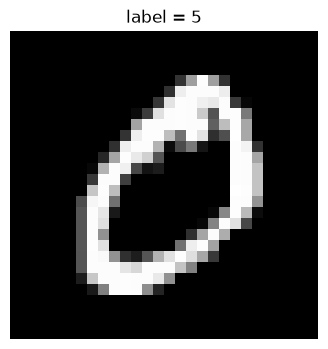

In [3]:
# a single image is just a 28x28 grid of numbers
img = x_train[1]
print('label:', y_train[0])
plt.figure(figsize=(4, 4))
plt.imshow(img, cmap='gray')
plt.grid(False); plt.axis('off')
plt.title(f'label = {y_train[0]}');

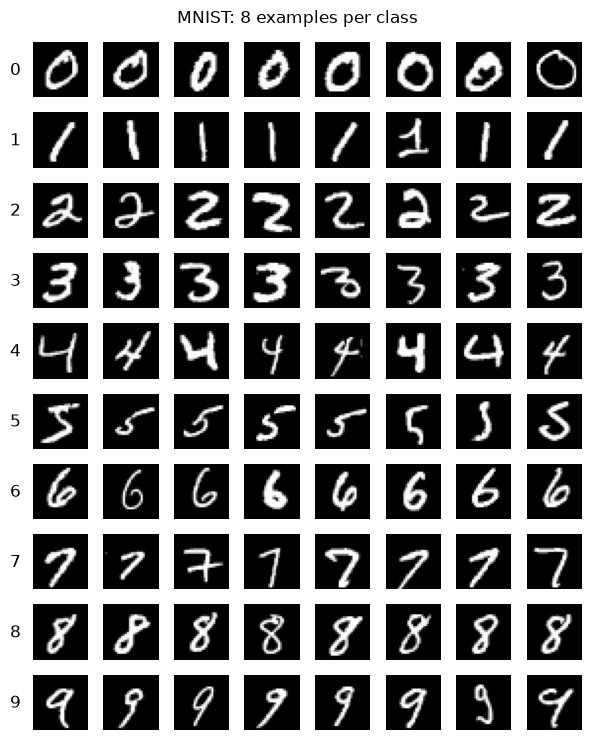

In [4]:
# 8 examples of every digit
fig, axes = plt.subplots(10, 8, figsize=(6, 7.5))
for digit in range(10):
  idx = np.where(y_train == digit)[0][:8]
  for j, i in enumerate(idx):
    ax = axes[digit, j]
    ax.imshow(x_train[i], cmap='gray')
    ax.axis('off')
  axes[digit, 0].text(-12, 14, str(digit), fontsize=12, va='center')
plt.suptitle('MNIST: 8 examples per class')
plt.tight_layout()

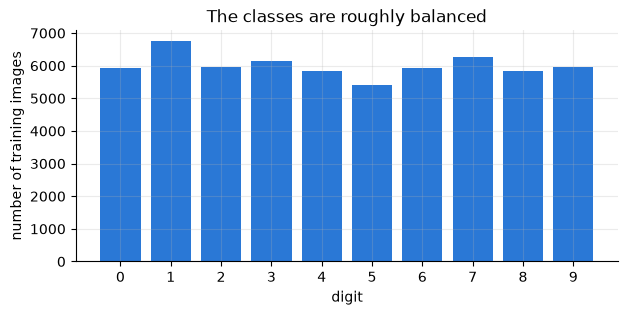

In [5]:
counts = np.bincount(y_train, minlength=10)
plt.figure(figsize=(7, 3))
plt.bar(range(10), counts, color=BLUE, width=0.8)
plt.xticks(range(10))
plt.xlabel('digit'); plt.ylabel('number of training images')
plt.title('The classes are roughly balanced');

### Preparing the inputs

- **Flatten** each 28x28 image into a vector of 784 numbers (one input per pixel, like `x1, x2, ...` in micrograd).
- **Normalize** the pixels to be roughly zero-mean, unit-variance. Neurons are happiest when inputs are around 0.
- Split into **train** (50k), **validation** (10k, to watch overfitting), and **test** (10k, touched once at the end).

In [6]:
X = x_train.reshape(-1, 784).astype(np.float64) / 255.0
Xte = x_test.reshape(-1, 784).astype(np.float64) / 255.0

mean, std = X[:50000].mean(), X[:50000].std()   # statistics from the training split only
X = (X - mean) / std
Xte = (Xte - mean) / std

Xtr, Ytr = X[:50000], y_train[:50000]
Xval, Yval = X[50000:], y_train[50000:]
Yte = y_test

print('Xtr', Xtr.shape, 'Xval', Xval.shape, 'Xte', Xte.shape)
print(f'pixel mean {mean:.4f}, std {std:.4f}')

Xtr (50000, 784) Xval (10000, 784) Xte (10000, 784)
pixel mean 0.1310, std 0.3085


## 2. The model: micrograd neurons, stacked into matrices

In micrograd, one neuron was:
```python
act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
out = act.tanh()
```
A **layer** of 128 such neurons looking at 784 inputs is the same thing written as a matrix multiply. Put all the weights in a matrix `W1` of shape `(784, 128)` (column `j` = the 784 weights of neuron `j`) and all biases in a vector `b1` of shape `(128,)`:

```
h1     = tanh(X @ W1 + b1)       # (batch, 784)  -> (batch, 128)
h2     = tanh(h1 @ W2 + b2)      # (batch, 128)  -> (batch, 64)
logits = h2 @ W3 + b3            # (batch, 64)   -> (batch, 10)   one score per digit
probs  = softmax(logits)
loss   = -mean(log(probs[correct digit]))     # cross-entropy
```

Architecture: **784 -> 128 (tanh) -> 64 (tanh) -> 10**.

In [7]:
n_in, n_h1, n_h2, n_out = 784, 128, 64, 10
names = ['W1', 'b1', 'W2', 'b2', 'W3', 'b3']

def forward(X, P):
  # returns the logits plus everything we need for backprop and visualization
  z1 = X @ P['W1'] + P['b1']
  h1 = np.tanh(z1)
  z2 = h1 @ P['W2'] + P['b2']
  h2 = np.tanh(z2)
  logits = h2 @ P['W3'] + P['b3']
  return logits, dict(X=X, z1=z1, h1=h1, z2=z2, h2=h2, logits=logits)

def softmax(logits):
  z = logits - logits.max(axis=1, keepdims=True)   # subtract max for numerical stability
  e = np.exp(z)
  return e / e.sum(axis=1, keepdims=True)

def cross_entropy(logits, Y):
  probs = softmax(logits)
  return -np.log(probs[np.arange(len(Y)), Y] + 1e-12).mean()

n_params = n_in*n_h1 + n_h1 + n_h1*n_h2 + n_h2 + n_h2*n_out + n_out
print('number of parameters:', n_params)

number of parameters: 109386


## 3. Initialization: what should happen at step 0?

Before training, the network knows nothing. The *right* thing for it to say is "every digit is equally likely": probability `1/10` for each class. So the loss we **expect** at initialization is:

$$\text{loss}_0 = -\ln(1/10) \approx 2.303$$

If the initial loss is much bigger than that, the network is **confidently wrong** at init, and the first part of training gets wasted just undoing that. Let's check.

In [8]:
expected_init_loss = -math.log(1/10)
print(f'expected loss at init: {expected_init_loss:.4f}')

expected loss at init: 2.3026


### A careless initialization

The most obvious thing: fill every weight and bias with `np.random.randn` (standard normal), like `random.uniform(-1, 1)` in micrograd's `Neuron`.

In [9]:
def init_params(scheme, seed=1337):
  rng = np.random.default_rng(seed)
  if scheme == 'naive':
    P = dict(
      W1 = rng.standard_normal((n_in, n_h1)),
      b1 = rng.standard_normal(n_h1),
      W2 = rng.standard_normal((n_h1, n_h2)),
      b2 = rng.standard_normal(n_h2),
      W3 = rng.standard_normal((n_h2, n_out)),
      b3 = rng.standard_normal(n_out),
    )
  elif scheme == 'fixed':
    # Kaiming init for tanh: std = gain / sqrt(fan_in), gain = 5/3
    gain = 5/3
    P = dict(
      W1 = rng.standard_normal((n_in, n_h1)) * gain / math.sqrt(n_in),
      b1 = rng.standard_normal(n_h1) * 0.01,
      W2 = rng.standard_normal((n_h1, n_h2)) * gain / math.sqrt(n_h1),
      b2 = rng.standard_normal(n_h2) * 0.01,
      W3 = rng.standard_normal((n_h2, n_out)) * 0.01,   # tiny output layer -> logits near 0
      b3 = np.zeros(n_out),                              # no class preferred at the start
    )
  return P

P_naive = init_params('naive')
batch = Xtr[:1000]; ybatch = Ytr[:1000]
logits, cache_naive = forward(batch, P_naive)
print(f'naive init loss: {cross_entropy(logits, ybatch):.4f}   (expected {expected_init_loss:.4f})')

naive init loss: 11.6302   (expected 2.3026)


true label: 5
logits: [  0.8  -0.9   4.1   1.8  -0.   -3.1  -4.4 -10.6   2.8  -0.5]


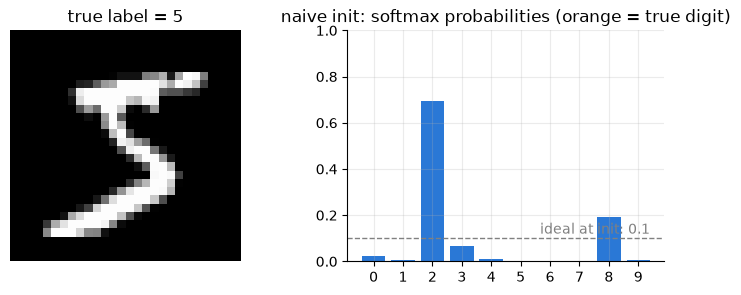

In [10]:
# look at ONE example: the logits are huge, so softmax is extremely confident, and usually wrong
i = 0
probs = softmax(logits[i:i+1])[0]
print('true label:', ybatch[i])
print('logits:', np.round(logits[i], 1))

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].imshow(batch[i].reshape(28, 28), cmap='gray'); axes[0].axis('off'); axes[0].grid(False)
axes[0].set_title(f'true label = {ybatch[i]}')
colors = [ORANGE if k == ybatch[i] else BLUE for k in range(10)]
axes[1].bar(range(10), probs, color=colors)
axes[1].set_xticks(range(10)); axes[1].set_ylim(0, 1)
axes[1].axhline(0.1, color='gray', ls='--', lw=1)
axes[1].text(9.4, 0.12, 'ideal at init: 0.1', ha='right', color='gray')
axes[1].set_title('naive init: softmax probabilities (orange = true digit)');

### The hidden problem: saturated tanh

Remember from micrograd: `o = tanh(n)`, and the local gradient is `do/dn = 1 - o**2`.

If `|o|` is close to 1, then `1 - o**2` is close to **0**, and the gradient flowing through that neuron **dies**. With big weights, `X @ W1 + b1` is a big number, so `tanh` squashes almost everything to exactly -1 or +1.

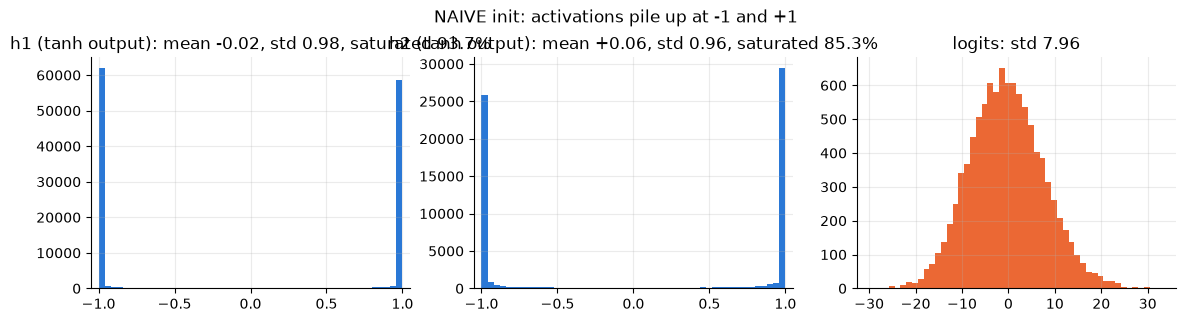

In [11]:
def plot_activation_stats(cache, title):
  fig, axes = plt.subplots(1, 3, figsize=(14, 3))
  for ax, key in zip(axes[:2], ['h1', 'h2']):
    h = cache[key]
    sat = (np.abs(h) > 0.97).mean() * 100
    ax.hist(h.ravel(), bins=50, color=BLUE)
    ax.set_title(f'{key} (tanh output): mean {h.mean():+.2f}, std {h.std():.2f}, saturated {sat:.1f}%')
    ax.set_xlim(-1.05, 1.05)
  axes[2].hist(cache['logits'].ravel(), bins=50, color=ORANGE)
  axes[2].set_title(f'logits: std {cache["logits"].std():.2f}')
  fig.suptitle(title, y=1.04)

plot_activation_stats(cache_naive, 'NAIVE init: activations pile up at -1 and +1')

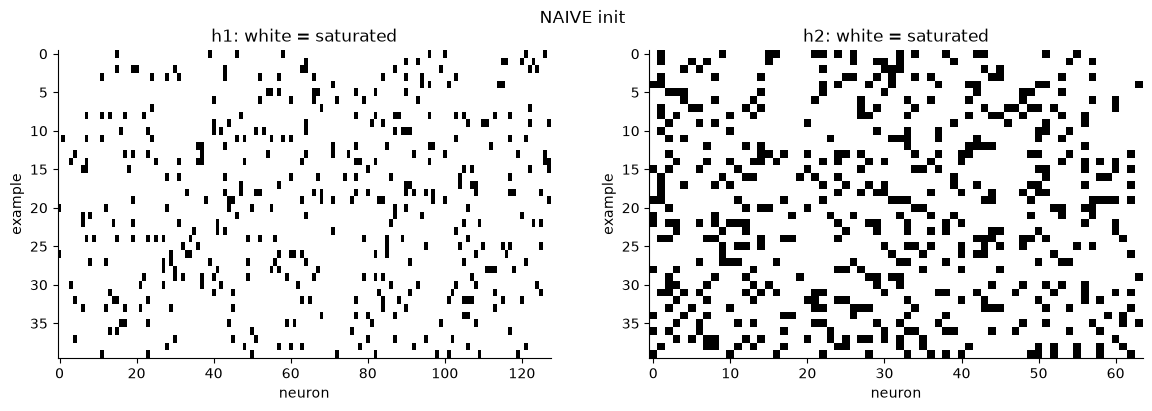

In [12]:
# Karpathy's favourite picture: each row is an example, each column is a neuron.
# WHITE = that neuron is saturated (|h| > 0.99) for that example -> its gradient is ~0.
# A column that is entirely white is a DEAD neuron: it will never learn, for any input.
def plot_saturation(cache, title):
  fig, axes = plt.subplots(1, 2, figsize=(14, 4))
  for ax, key in zip(axes, ['h1', 'h2']):
    h = cache[key][:40]
    ax.imshow(np.abs(h) > 0.99, cmap='gray', interpolation='nearest', aspect='auto', vmin=0, vmax=1)
    ax.grid(False)
    ax.set_xlabel('neuron'); ax.set_ylabel('example')
    ax.set_title(f'{key}: white = saturated')
  fig.suptitle(title)

plot_saturation(cache_naive, 'NAIVE init')

### Fixing the initialization

Two fixes, both straight from makemore part 3:

1. **Output layer**: make `W3` tiny and `b3 = 0`, so the logits start near 0, softmax is near uniform, and the loss starts near 2.303.
2. **Hidden layers**: scale weights by `gain / sqrt(fan_in)` (Kaiming init, `gain = 5/3` for tanh). Each neuron adds up `fan_in` inputs, so dividing by `sqrt(fan_in)` keeps the pre-activation at a sensible size instead of growing with the number of inputs.

fixed init loss: 2.2955   (expected 2.3026)


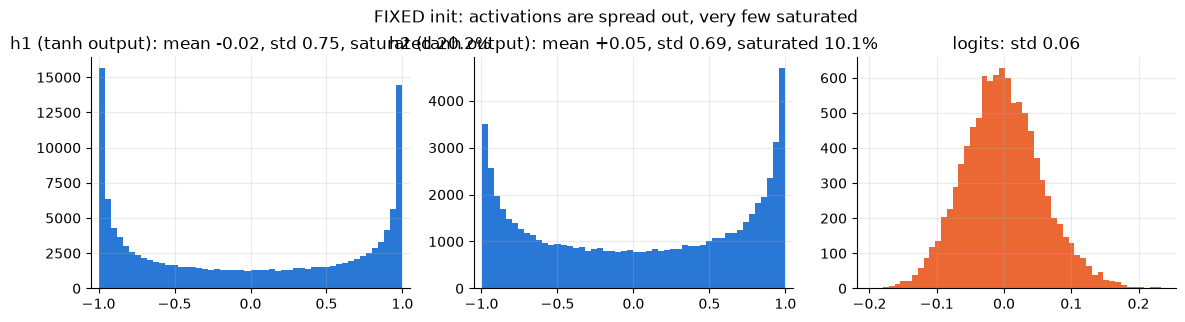

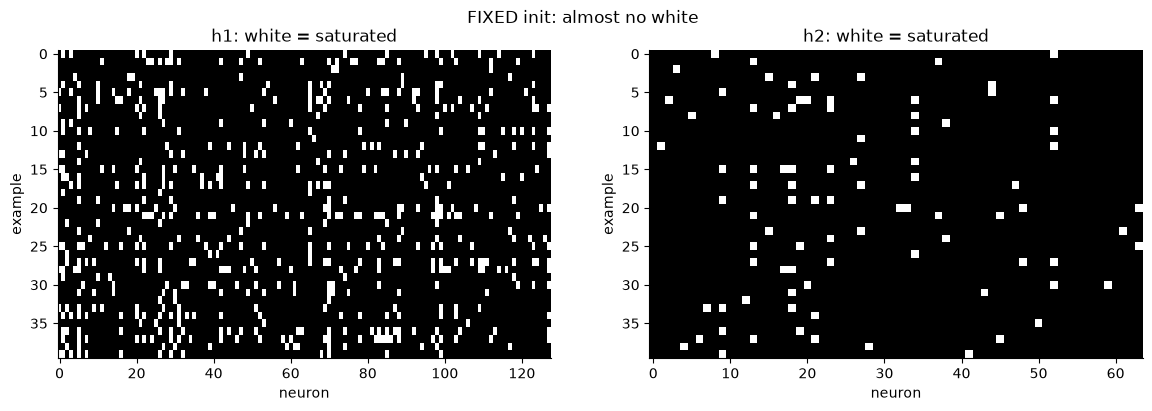

In [13]:
P_fixed = init_params('fixed')
logits, cache_fixed = forward(batch, P_fixed)
print(f'fixed init loss: {cross_entropy(logits, ybatch):.4f}   (expected {expected_init_loss:.4f})')
plot_activation_stats(cache_fixed, 'FIXED init: activations are spread out, very few saturated')
plot_saturation(cache_fixed, 'FIXED init: almost no white')

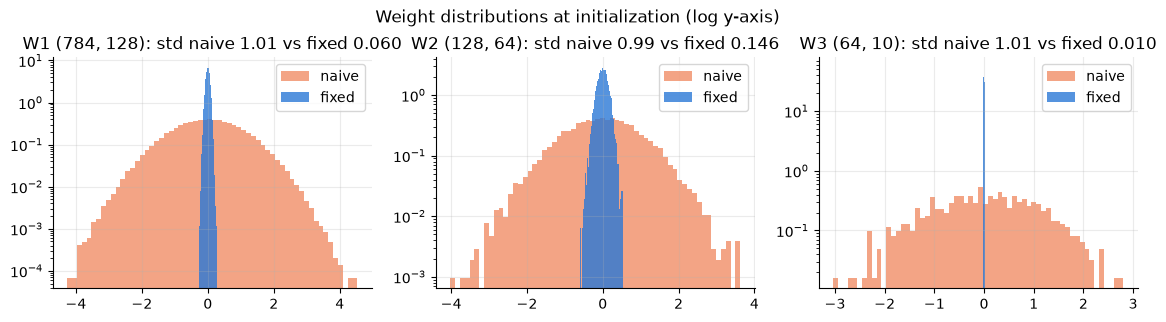

In [14]:
# what do the weights themselves look like at init?
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, name in zip(axes, ['W1', 'W2', 'W3']):
  ax.hist(P_naive[name].ravel(), bins=60, color=ORANGE, alpha=0.6, density=True, label='naive')
  ax.hist(P_fixed[name].ravel(), bins=60, color=BLUE, alpha=0.8, density=True, label='fixed')
  ax.set_title(f'{name} {P_fixed[name].shape}: std naive {P_naive[name].std():.2f} vs fixed {P_fixed[name].std():.3f}')
  ax.set_yscale('log')
  ax.legend()
fig.suptitle('Weight distributions at initialization (log y-axis)', y=1.04);

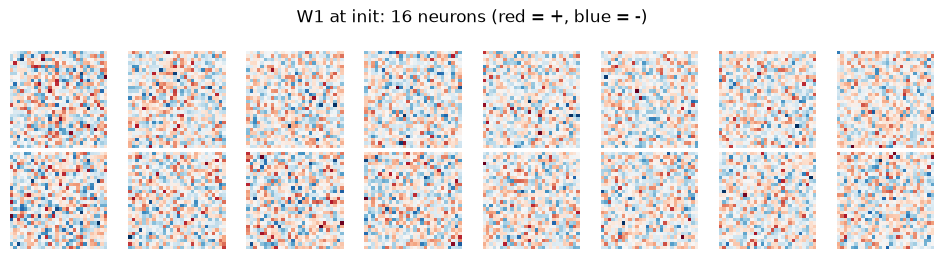

In [15]:
# First-layer weights of 16 neurons, reshaped back into 28x28 images.
# At init this is pure noise: the network has no idea what a digit looks like yet.
def show_neurons(W, n=16, title='', ncols=8):
  nrows = math.ceil(n / ncols)
  fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.2, nrows * 1.3))
  for j, ax in enumerate(axes.ravel()):
    w = W[:, j].reshape(28, 28)
    lim = np.abs(w).max()
    ax.imshow(w, cmap='RdBu_r', vmin=-lim, vmax=lim)   # red = positive weight, blue = negative
    ax.axis('off')
  fig.suptitle(title)
  plt.tight_layout()

show_neurons(P_fixed['W1'], title='W1 at init: 16 neurons (red = +, blue = -)')

## 4. Backpropagation by hand

This is micrograd's `_backward` functions, written for matrices. Go from the loss backwards, one line of the forward pass at a time:

| forward | backward |
|---|---|
| `loss = cross_entropy(logits, Y)` | `dlogits = (softmax(logits) - onehot(Y)) / batch` |
| `logits = h2 @ W3 + b3` | `dW3 = h2.T @ dlogits`, `db3 = dlogits.sum(0)`, `dh2 = dlogits @ W3.T` |
| `h2 = tanh(z2)` | `dz2 = (1 - h2**2) * dh2`   (same `1 - o**2` as micrograd!) |
| `z2 = h1 @ W2 + b2` | `dW2 = h1.T @ dz2`, `db2 = dz2.sum(0)`, `dh1 = dz2 @ W2.T` |
| `h1 = tanh(z1)` | `dz1 = (1 - h1**2) * dh1` |
| `z1 = X @ W1 + b1` | `dW1 = X.T @ dz1`, `db1 = dz1.sum(0)`, `dX = dz1 @ W1.T` |

Biases get `.sum(0)` because the same bias was used for every example in the batch, and in micrograd a value used many times **accumulates** (`+=`) its gradient.

In [16]:
def backward(cache, P, dlogits):
  # given dloss/dlogits, return gradients for all parameters (and for the input X)
  X, h1, h2 = cache['X'], cache['h1'], cache['h2']
  G = {}
  G['W3'] = h2.T @ dlogits
  G['b3'] = dlogits.sum(0)
  dh2 = dlogits @ P['W3'].T
  dz2 = (1 - h2**2) * dh2
  G['W2'] = h1.T @ dz2
  G['b2'] = dz2.sum(0)
  dh1 = dz2 @ P['W2'].T
  dz1 = (1 - h1**2) * dh1
  G['W1'] = X.T @ dz1
  G['b1'] = dz1.sum(0)
  G['X'] = dz1 @ P['W1'].T
  return G

def loss_and_grads(X, Y, P):
  logits, cache = forward(X, P)
  loss = cross_entropy(logits, Y)
  dlogits = softmax(logits)
  dlogits[np.arange(len(Y)), Y] -= 1
  dlogits /= len(Y)
  return loss, backward(cache, P, dlogits), cache

### Gradient check

Do we trust our calculus? Use the same trick as the very start of micrograd: nudge one number by `h` and see how much the loss moves.

$$\frac{\partial L}{\partial w} \approx \frac{L(w + h) - L(w - h)}{2h}$$

In [17]:
P = init_params('fixed', seed=0)
xb, yb = Xtr[:32], Ytr[:32]
loss, G, _ = loss_and_grads(xb, yb, P)

h = 1e-5
rng = np.random.default_rng(0)
print(f'{"param":>6} {"index":>12} {"analytic":>12} {"numerical":>12} {"rel. error":>11}')
for name in names:
  for _ in range(2):
    idx = tuple(int(rng.integers(0, s)) for s in P[name].shape)
    old = P[name][idx]
    P[name][idx] = old + h; lp = cross_entropy(forward(xb, P)[0], yb)
    P[name][idx] = old - h; lm = cross_entropy(forward(xb, P)[0], yb)
    P[name][idx] = old
    num = (lp - lm) / (2*h)
    ana = G[name][idx]
    rel = abs(num - ana) / max(1e-12, abs(num) + abs(ana))
    print(f'{name:>6} {str(idx):>12} {ana:12.8f} {num:12.8f} {rel:11.2e}')

 param        index     analytic    numerical  rel. error
    W1    (666, 81)   0.00044982   0.00044982    1.16e-08
    W1    (400, 34)  -0.00075597  -0.00075597    3.70e-09
    b1        (39,)  -0.00109451  -0.00109451    7.64e-09
    b1         (5,)  -0.00127923  -0.00127923    1.04e-08
    W2       (9, 1)   0.00085075   0.00085075    6.64e-09
    W2     (22, 52)   0.00047099   0.00047099    1.63e-08
    b2        (41,)   0.00320697   0.00320697    1.50e-09
    b2        (58,)  -0.00059207  -0.00059207    2.16e-09
    W3      (32, 6)  -0.04265283  -0.04265283    1.03e-10
    W3      (62, 7)  -0.02627769  -0.02627769    6.62e-11
    b3         (6,)   0.03678182   0.03678182    2.29e-10
    b3         (5,)   0.03218648   0.03218648    2.06e-10


Relative errors around `1e-7` or smaller mean the backward pass is correct.

## 5. Training, while recording everything

The loop is identical to micrograd's:
```python
for k in range(steps):
  # forward pass
  # backward pass
  # update: p.data += -lr * p.grad
```
The only differences: we use a random **minibatch** of 64 images each step (instead of the whole dataset), and we record statistics so we can look inside afterwards.

In [18]:
def evaluate(X, Y, P, bs=5000):
  losses, correct = [], 0
  for i in range(0, len(X), bs):
    logits, _ = forward(X[i:i+bs], P)
    losses.append(cross_entropy(logits, Y[i:i+bs]) * len(X[i:i+bs]))
    correct += (logits.argmax(1) == Y[i:i+bs]).sum()
  return sum(losses) / len(X), correct / len(X)

def train(scheme, max_steps=10000, batch_size=64, seed=1337, verbose=True):
  P = init_params(scheme, seed=seed)
  P0 = {k: v.copy() for k, v in P.items()}        # remember the initial weights
  rng = np.random.default_rng(seed)

  H = dict(loss=[], val_step=[], val_loss=[], val_acc=[],
           ud={n: [] for n in names},              # update:data ratios
           grad_std={n: [] for n in names},
           W1_snapshots={}, track=[])
  snapshot_steps = {0, 100, 500, 2000, max_steps - 1}

  for i in range(max_steps):
    # minibatch
    ix = rng.integers(0, len(Xtr), batch_size)
    xb, yb = Xtr[ix], Ytr[ix]

    # forward + backward
    loss, G, cache = loss_and_grads(xb, yb, P)

    # update (learning rate decay after 75% of training)
    lr = 0.1 if i < int(0.75 * max_steps) else 0.01
    for n in names:
      update = -lr * G[n]
      H['ud'][n].append(np.log10(update.std() / (P[n].std() + 1e-12) + 1e-12))
      H['grad_std'][n].append(G[n].std())
      P[n] += update

    # bookkeeping
    H['loss'].append(loss)
    # follow a handful of individual numbers through training
    H['track'].append([P['W1'][406, 0], P['W1'][350, 5], P['b1'][0], P['W3'][0, 3], P['b3'][1], P['b3'][8]])
    if i in snapshot_steps:
      H['W1_snapshots'][i] = P['W1'].copy()
    if i % 250 == 0 or i == max_steps - 1:
      vl, va = evaluate(Xval, Yval, P)
      H['val_step'].append(i); H['val_loss'].append(vl); H['val_acc'].append(va)
      if verbose and (i % 1000 == 0 or i == max_steps - 1):
        print(f'step {i:6d}/{max_steps}  lr {lr:.2f}  batch loss {loss:.4f}  val loss {vl:.4f}  val acc {va*100:.2f}%')

  H['track'] = np.array(H['track'])
  return P, P0, H

In [19]:
P, P0, H = train('fixed')

step      0/10000  lr 0.10  batch loss 2.3032  val loss 2.2412  val acc 32.28%
step   1000/10000  lr 0.10  batch loss 0.2635  val loss 0.1660  val acc 95.45%
step   2000/10000  lr 0.10  batch loss 0.0435  val loss 0.1256  val acc 96.43%
step   3000/10000  lr 0.10  batch loss 0.0565  val loss 0.1087  val acc 96.91%
step   4000/10000  lr 0.10  batch loss 0.0422  val loss 0.1019  val acc 96.92%
step   5000/10000  lr 0.10  batch loss 0.0088  val loss 0.0934  val acc 97.35%
step   6000/10000  lr 0.10  batch loss 0.0378  val loss 0.0955  val acc 97.36%
step   7000/10000  lr 0.10  batch loss 0.0251  val loss 0.0933  val acc 97.40%
step   8000/10000  lr 0.01  batch loss 0.0540  val loss 0.0881  val acc 97.62%
step   9000/10000  lr 0.01  batch loss 0.0386  val loss 0.0888  val acc 97.63%
step   9999/10000  lr 0.01  batch loss 0.0098  val loss 0.0881  val acc 97.67%


In [20]:
# for comparison: exactly the same training, but with the careless init
P_bad, P0_bad, H_bad = train('naive', verbose=False)
print(f"naive init  -> final val loss {H_bad['val_loss'][-1]:.4f}, val acc {H_bad['val_acc'][-1]*100:.2f}%")
print(f"fixed init  -> final val loss {H['val_loss'][-1]:.4f}, val acc {H['val_acc'][-1]*100:.2f}%")

naive init  -> final val loss 0.4641, val acc 86.00%
fixed init  -> final val loss 0.0881, val acc 97.67%


## 6. The loss curve

The raw minibatch loss is very noisy (every batch is different), so we look at it three ways:
1. **raw**, per step
2. **log10**, so we can see the slow progress at the end
3. **smoothed**: average every 100 steps (Karpathy's `.view(-1, 100).mean(1)` trick), together with the validation loss

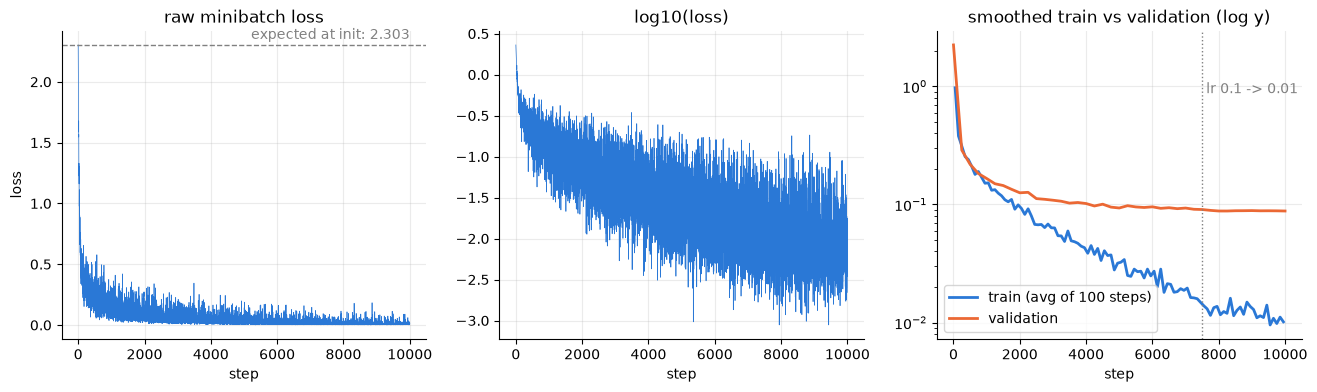

In [21]:
loss = np.array(H['loss'])
chunk = 100
smooth = loss[:len(loss)//chunk*chunk].reshape(-1, chunk).mean(1)
smooth_steps = np.arange(len(smooth)) * chunk + chunk/2

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(loss, color=BLUE, lw=0.5)
axes[0].axhline(expected_init_loss, color='gray', ls='--', lw=1)
axes[0].text(len(loss), expected_init_loss + 0.05, 'expected at init: 2.303', ha='right', color='gray')
axes[0].set_title('raw minibatch loss'); axes[0].set_xlabel('step'); axes[0].set_ylabel('loss')

axes[1].plot(np.log10(loss), color=BLUE, lw=0.5)
axes[1].set_title('log10(loss)'); axes[1].set_xlabel('step')

axes[2].plot(smooth_steps, smooth, color=BLUE, lw=2, label='train (avg of 100 steps)')
axes[2].plot(H['val_step'], H['val_loss'], color=ORANGE, lw=2, label='validation')
axes[2].axvline(int(0.75 * len(loss)), color='gray', ls=':', lw=1)
axes[2].text(int(0.75 * len(loss)), max(smooth) * 0.9, ' lr 0.1 -> 0.01', color='gray')
axes[2].set_yscale('log')
axes[2].set_title('smoothed train vs validation (log y)'); axes[2].set_xlabel('step')
axes[2].legend();

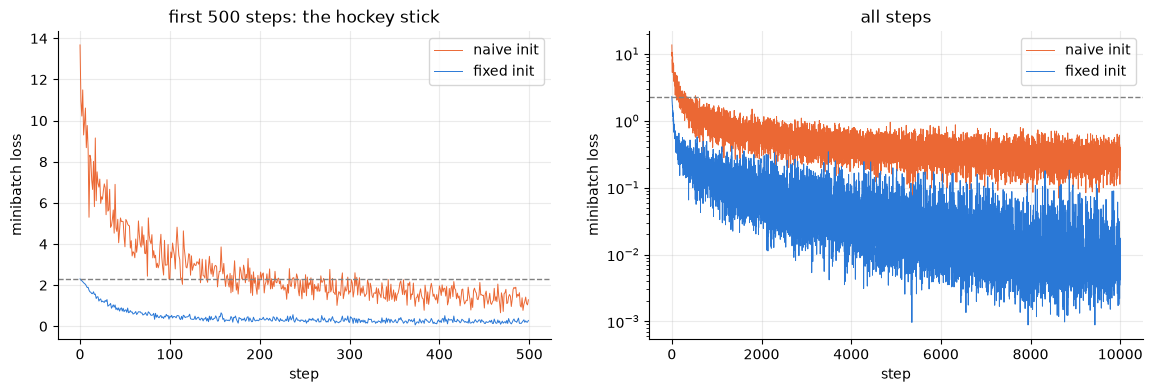

In [22]:
# the naive init wastes the start of training: the famous "hockey stick"
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, n_show in zip(axes, [500, len(loss)]):
  ax.plot(H_bad['loss'][:n_show], color=ORANGE, lw=0.7, label='naive init')
  ax.plot(H['loss'][:n_show], color=BLUE, lw=0.7, label='fixed init')
  ax.axhline(expected_init_loss, color='gray', ls='--', lw=1)
  ax.set_xlabel('step'); ax.set_ylabel('minibatch loss')
  ax.legend()
axes[0].set_title('first 500 steps: the hockey stick')
axes[1].set_title('all steps'); axes[1].set_yscale('log');

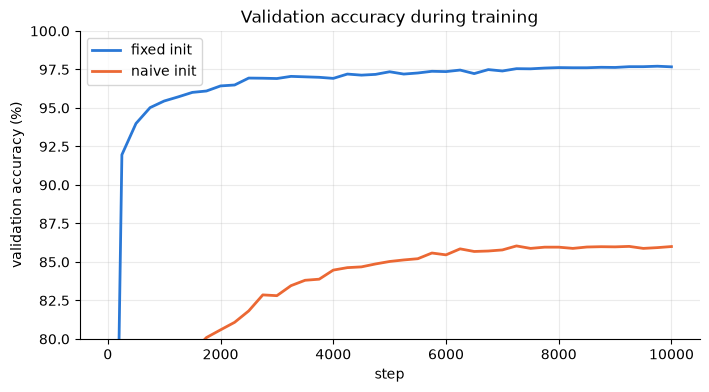

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(H['val_step'], np.array(H['val_acc']) * 100, color=BLUE, lw=2, label='fixed init')
plt.plot(H_bad['val_step'], np.array(H_bad['val_acc']) * 100, color=ORANGE, lw=2, label='naive init')
plt.ylim(80, 100)
plt.xlabel('step'); plt.ylabel('validation accuracy (%)')
plt.title('Validation accuracy during training')
plt.legend();

## 7. How did the weights and biases change?

### 7a. Following individual numbers

The network is just 110,000 numbers being nudged by `-lr * grad` every step. Let's follow six of them.

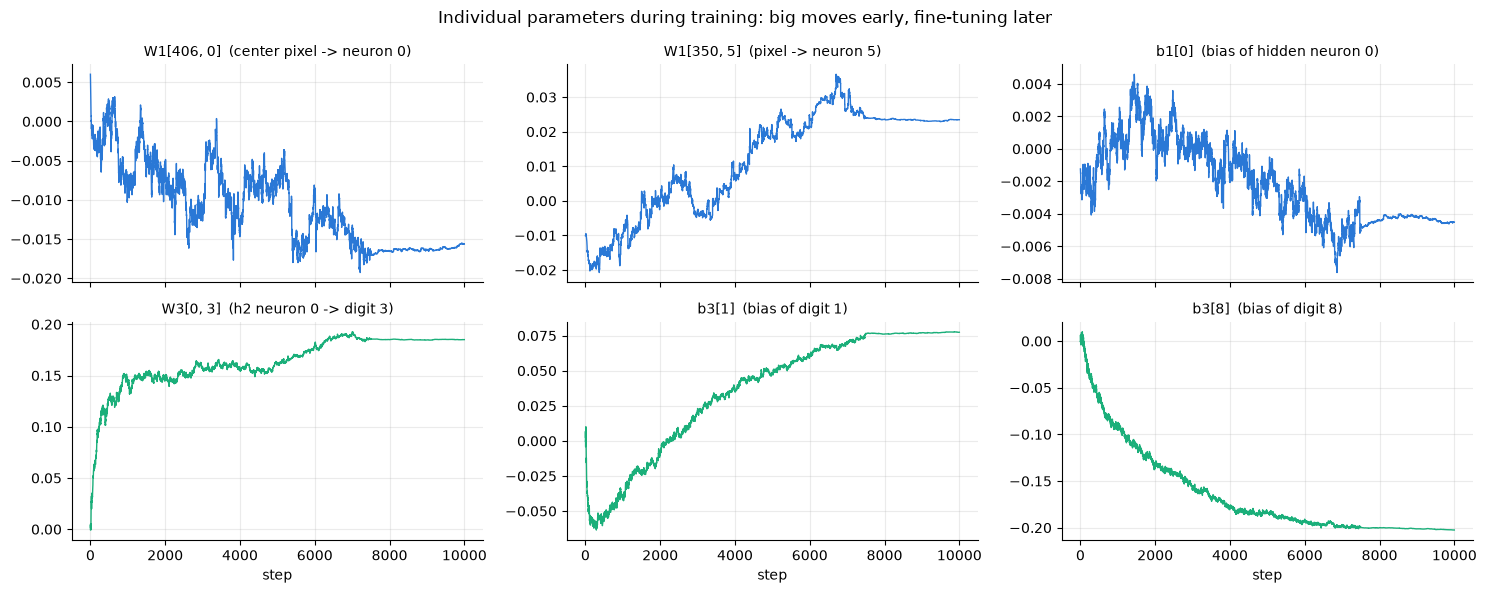

In [24]:
labels = ['W1[406, 0]  (center pixel -> neuron 0)', 'W1[350, 5]  (pixel -> neuron 5)', 'b1[0]  (bias of hidden neuron 0)',
          'W3[0, 3]  (h2 neuron 0 -> digit 3)', 'b3[1]  (bias of digit 1)', 'b3[8]  (bias of digit 8)']
fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True)
for k, ax in enumerate(axes.ravel()):
  ax.plot(H['track'][:, k], color=BLUE if k < 3 else AQUA, lw=1)
  ax.set_title(labels[k], fontsize=10)
for ax in axes[1]: ax.set_xlabel('step')
fig.suptitle('Individual parameters during training: big moves early, fine-tuning later')
plt.tight_layout()

### 7b. Weight and bias distributions: before vs after

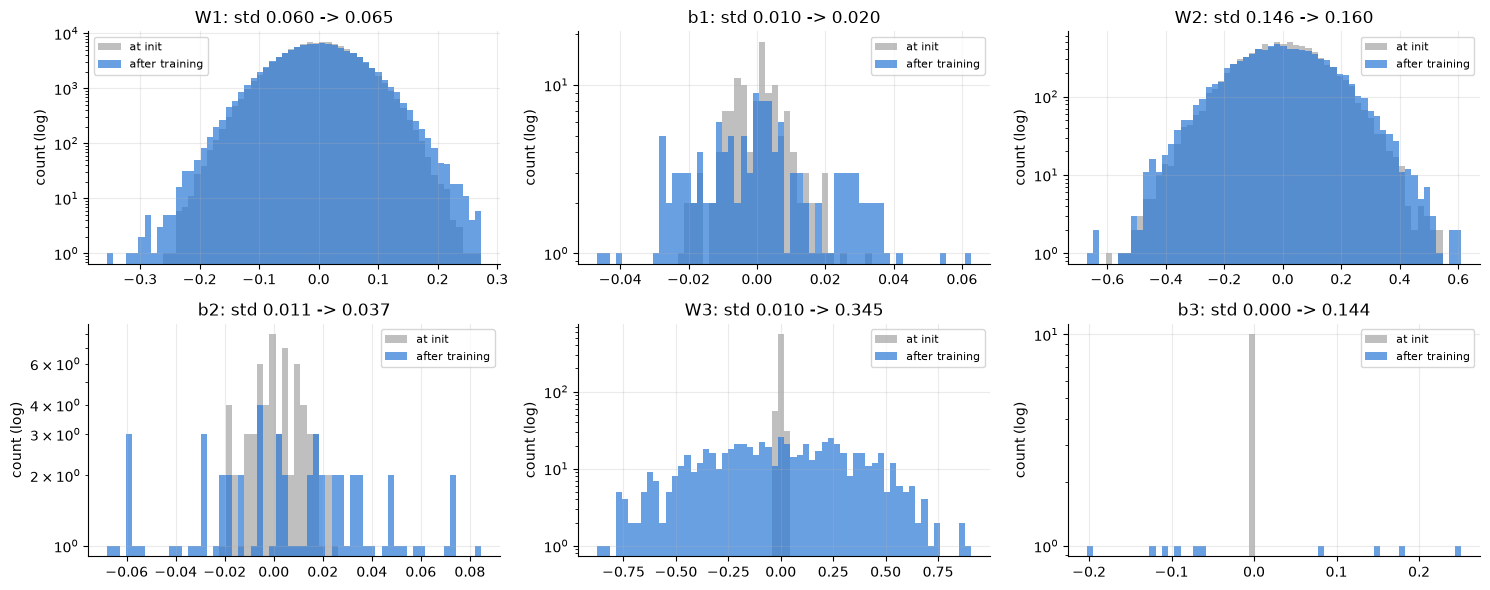

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for j, name in enumerate(names):
  ax = axes.ravel()[j]
  bins = np.histogram_bin_edges(np.concatenate([P0[name].ravel(), P[name].ravel()]), bins=60)
  ax.hist(P0[name].ravel(), bins=bins, color='gray', alpha=0.5, label='at init')
  ax.hist(P[name].ravel(), bins=bins, color=BLUE, alpha=0.7, label='after training')
  ax.set_yscale('log'); ax.set_ylabel('count (log)')
  ax.set_title(f'{name}: std {P0[name].std():.3f} -> {P[name].std():.3f}')
  ax.legend(fontsize=8)
plt.tight_layout()

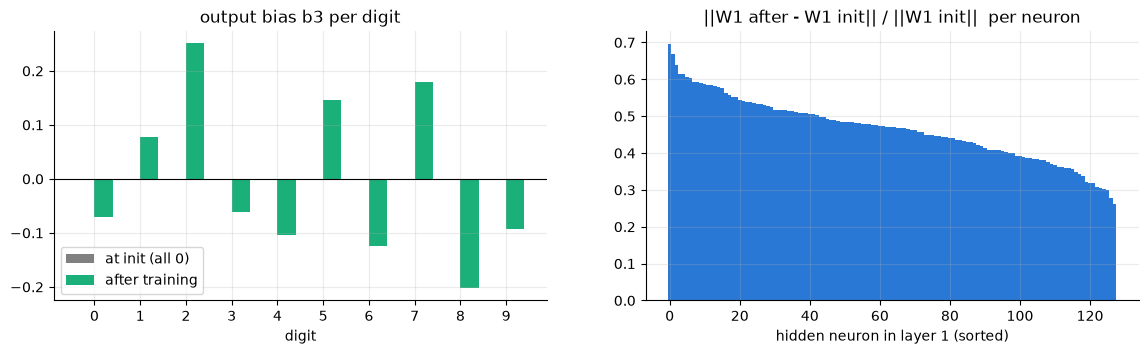

In [26]:
# the output biases b3: one number per digit, how much the network "prefers" each class before looking
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
x = np.arange(10)
axes[0].bar(x - 0.2, P0['b3'], width=0.4, color='gray', label='at init (all 0)')
axes[0].bar(x + 0.2, P['b3'], width=0.4, color=AQUA, label='after training')
axes[0].set_xticks(x); axes[0].set_xlabel('digit'); axes[0].set_title('output bias b3 per digit')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].legend()

# how much did each hidden neuron's incoming weights move?
moved = np.linalg.norm(P['W1'] - P0['W1'], axis=0) / np.linalg.norm(P0['W1'], axis=0)
axes[1].bar(range(n_h1), np.sort(moved)[::-1], color=BLUE, width=1.0)
axes[1].set_xlabel('hidden neuron in layer 1 (sorted)')
axes[1].set_title('||W1 after - W1 init|| / ||W1 init||  per neuron');

### 7c. The update:data ratio

A great health check from makemore part 3: for each parameter, how big is the update compared to the parameter itself?

$$\log_{10}\left(\frac{\text{std}(\text{lr} \cdot \text{grad})}{\text{std}(\text{param})}\right)$$

A rough rule of thumb: around **-3** (each step changes the weights by about 1/1000 of their size). Much higher means the learning rate is too large and things thrash; much lower means learning is painfully slow. Watch the whole curve drop by 1 when we cut the learning rate by 10x.

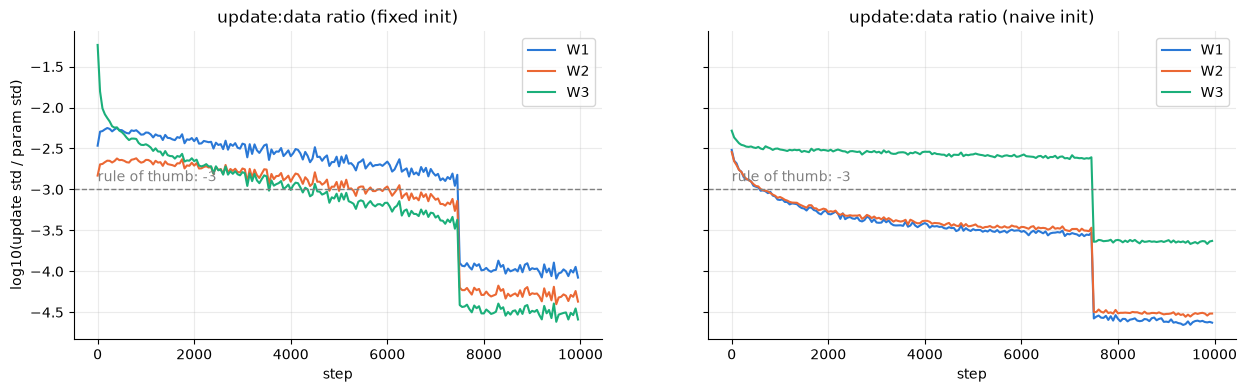

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
colors = [BLUE, ORANGE, AQUA]
for ax, hist, title in [(axes[0], H, 'fixed init'), (axes[1], H_bad, 'naive init')]:
  for c, name in zip(colors, ['W1', 'W2', 'W3']):
    ud = np.array(hist['ud'][name])
    ud = ud[:len(ud)//50*50].reshape(-1, 50).mean(1)
    ax.plot(np.arange(len(ud)) * 50, ud, color=c, lw=1.5, label=name)
  ax.axhline(-3, color='gray', ls='--', lw=1)
  ax.text(0, -2.9, 'rule of thumb: -3', color='gray')
  ax.set_title(f'update:data ratio ({title})'); ax.set_xlabel('step')
  ax.legend()
axes[0].set_ylabel('log10(update std / param std)');

### 7d. Gradient flow

If some layer's gradients are much smaller than the others, that layer is barely learning. With the naive init, saturated tanh units choke the gradient to the first layer.

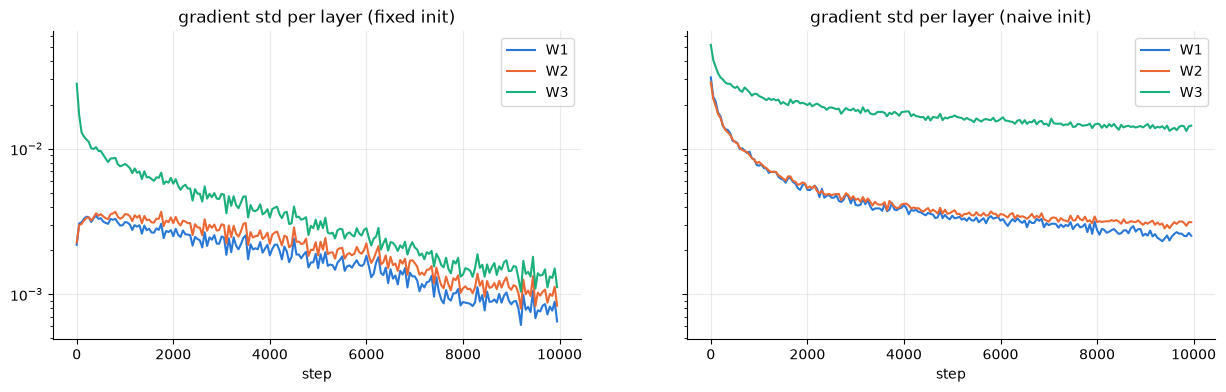

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
for ax, hist, title in [(axes[0], H, 'fixed init'), (axes[1], H_bad, 'naive init')]:
  for c, name in zip(colors, ['W1', 'W2', 'W3']):
    g = np.array(hist['grad_std'][name])
    g = g[:len(g)//50*50].reshape(-1, 50).mean(1)
    ax.plot(np.arange(len(g)) * 50, g, color=c, lw=1.5, label=name)
  ax.set_yscale('log')
  ax.set_title(f'gradient std per layer ({title})'); ax.set_xlabel('step')
  ax.legend()

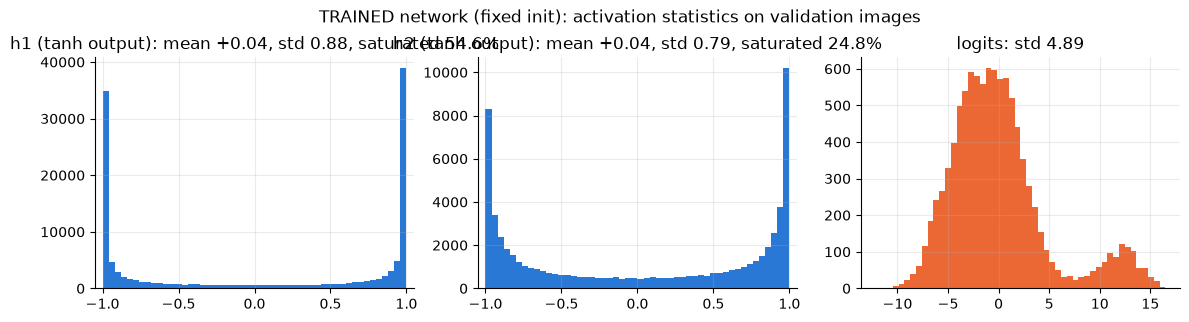

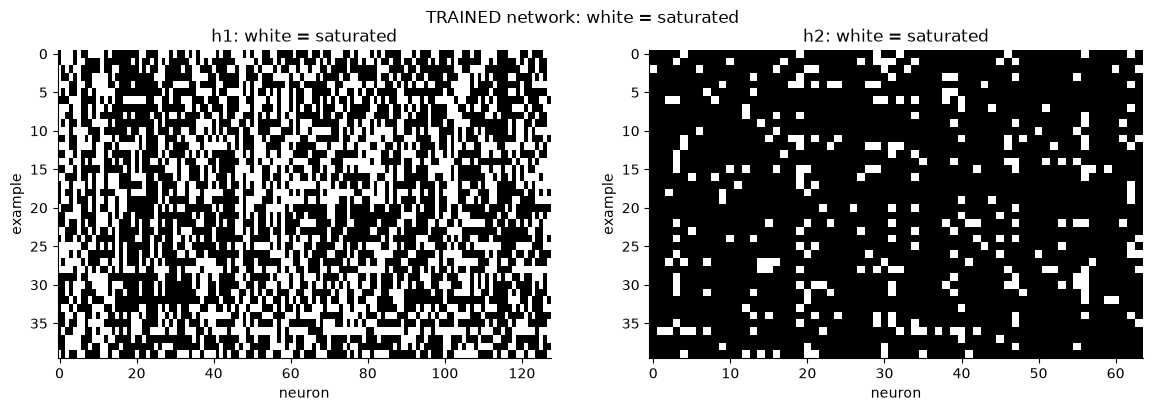

In [29]:
# activations after training: is the network still healthy?
_, cache_trained = forward(Xval[:1000], P)
plot_activation_stats(cache_trained, 'TRAINED network (fixed init): activation statistics on validation images')
plot_saturation(cache_trained, 'TRAINED network: white = saturated')

## 8. What does the network see?

### 8a. First-layer weights as images

Column `j` of `W1` has 784 numbers, one per pixel. Reshape it to 28x28 and it shows **the pattern neuron `j` is looking for**: red pixels push the neuron up, blue pixels push it down.

Here is the same set of neurons at several moments in training. The weights started as random noise, so the most informative picture is the **change since initialization**, which is exactly what gradient descent added.

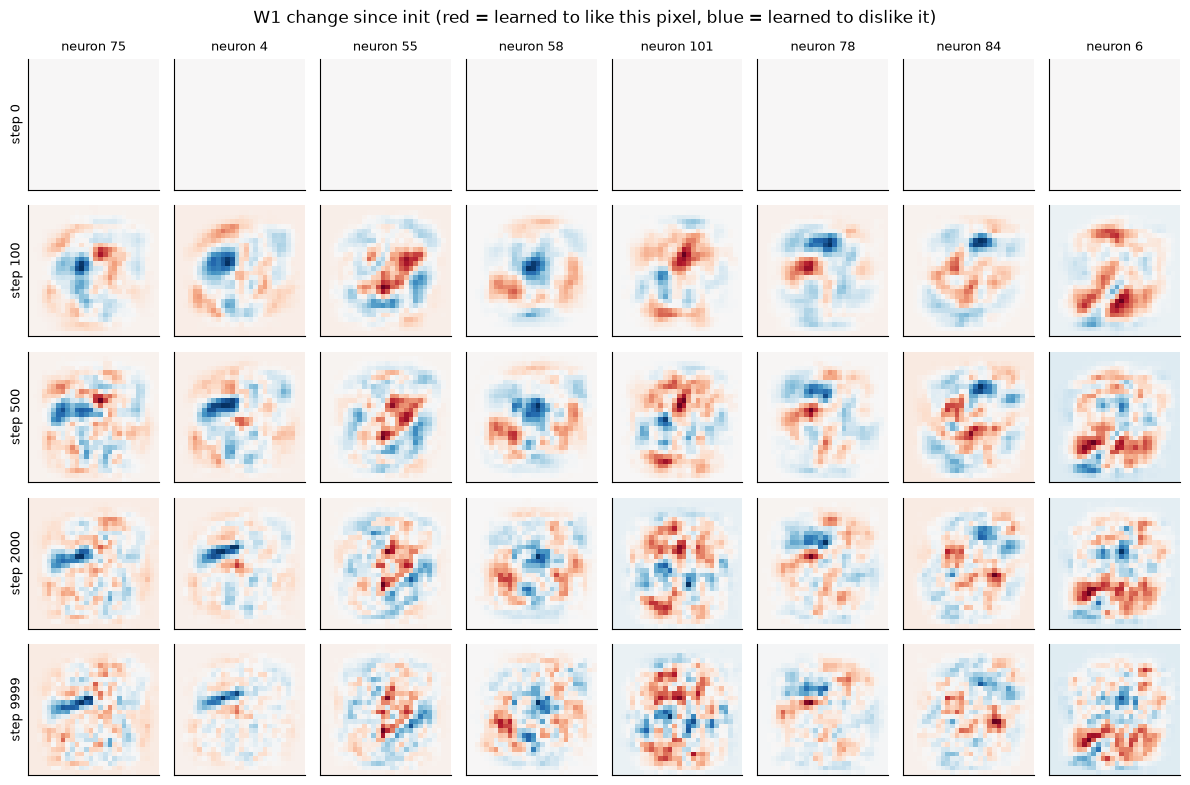

In [30]:
steps = sorted(H['W1_snapshots'].keys())
neurons = np.argsort(moved)[::-1][:8]      # the 8 neurons that changed the most

fig, axes = plt.subplots(len(steps), len(neurons), figsize=(12, 1.6 * len(steps)))
for r, s in enumerate(steps):
  delta = H['W1_snapshots'][s] - H['W1_snapshots'][0]
  for c, j in enumerate(neurons):
    ax = axes[r, c]
    w = delta[:, j].reshape(28, 28)
    lim = np.abs(w).max() + 1e-12
    ax.imshow(w, cmap='RdBu_r', vmin=-lim, vmax=lim)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    if c == 0: ax.set_ylabel(f'step {s}', fontsize=9)
    if r == 0: ax.set_title(f'neuron {j}', fontsize=9)
fig.suptitle('W1 change since init (red = learned to like this pixel, blue = learned to dislike it)')
plt.tight_layout()

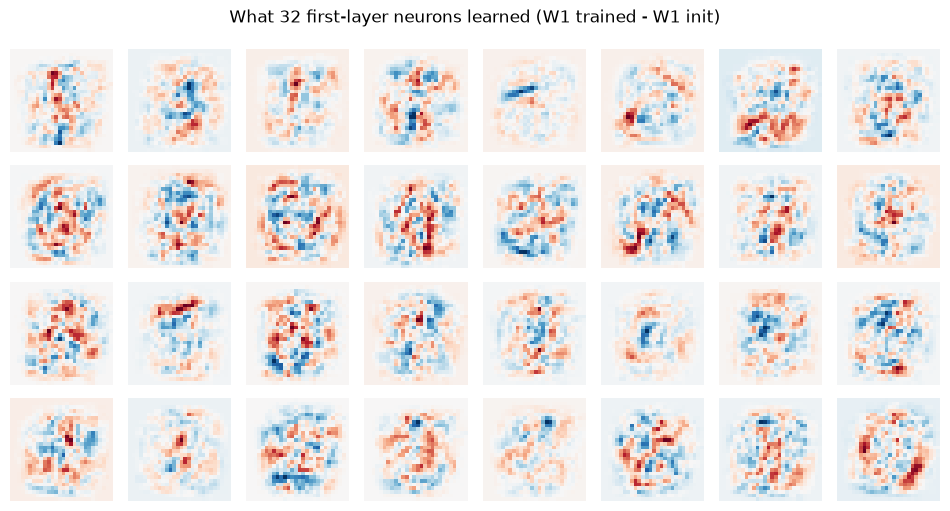

In [31]:
show_neurons(P['W1'] - P0['W1'], n=32, title='What 32 first-layer neurons learned (W1 trained - W1 init)')

### 8b. What excites a neuron?

Another way to see what a neuron detects: run all validation images through the network and show the ones that make that neuron fire the hardest.

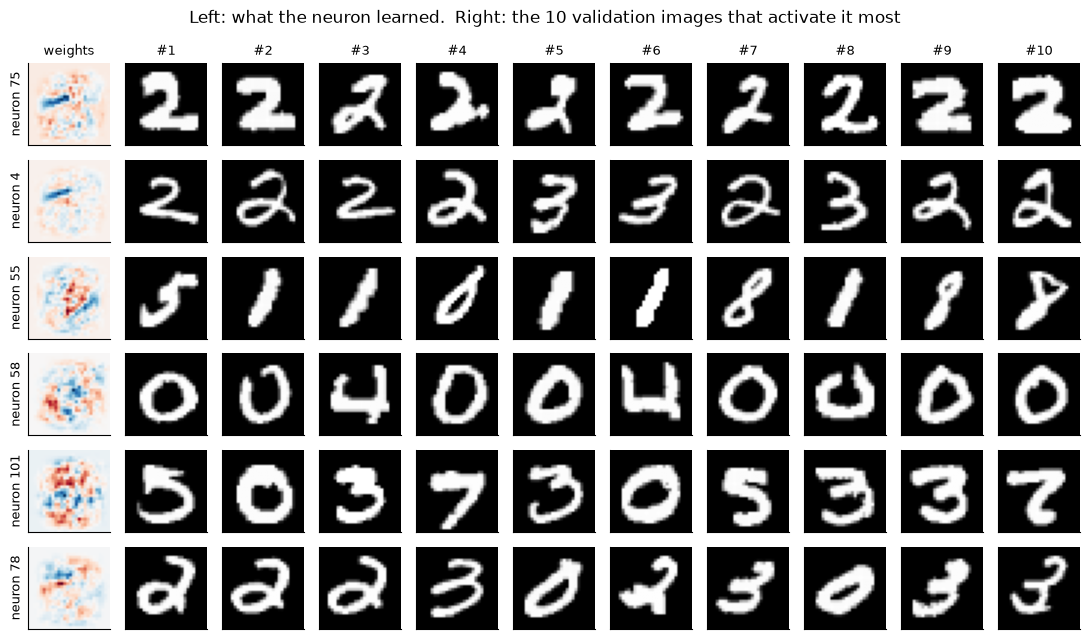

In [32]:
_, cache_val = forward(Xval, P)
fig, axes = plt.subplots(6, 11, figsize=(11, 6.5))
for r, j in enumerate(neurons[:6]):
  w = (P['W1'] - P0['W1'])[:, j].reshape(28, 28)
  lim = np.abs(w).max()
  axes[r, 0].imshow(w, cmap='RdBu_r', vmin=-lim, vmax=lim)
  axes[r, 0].set_ylabel(f'neuron {j}', fontsize=9)
  top = np.argsort(cache_val['h1'][:, j])[::-1][:10]
  for c, i in enumerate(top):
    axes[r, c+1].imshow(Xval[i].reshape(28, 28), cmap='gray')
for ax in axes.ravel():
  ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
axes[0, 0].set_title('weights', fontsize=9)
for c in range(10): axes[0, c+1].set_title(f'#{c+1}', fontsize=9)
fig.suptitle('Left: what the neuron learned.  Right: the 10 validation images that activate it most')
plt.tight_layout()

### 8c. Class templates (the CS231n picture)

Hidden layers mix things up, so individual neurons are hard to name. If we remove the hidden layers and train a plain **linear classifier** (`logits = X @ W + b`, straight from 784 pixels to 10 scores), then each digit gets exactly one 28x28 weight image: a **template**. The score for "3" is literally the dot product of the image with the "3" template.

linear classifier validation accuracy: 92.04%  (vs 97.67% for the MLP)


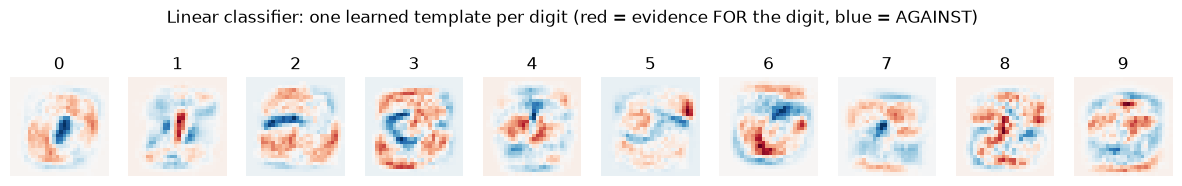

In [33]:
rng = np.random.default_rng(0)
W_lin = np.zeros((784, 10))
b_lin = np.zeros(10)
lin_loss = []
for i in range(3000):
  ix = rng.integers(0, len(Xtr), 128)
  xb, yb = Xtr[ix], Ytr[ix]
  logits = xb @ W_lin + b_lin
  lin_loss.append(cross_entropy(logits, yb))
  dlogits = softmax(logits); dlogits[np.arange(len(yb)), yb] -= 1; dlogits /= len(yb)
  W_lin -= 0.05 * (xb.T @ dlogits + 1e-2 * W_lin)   # L2 regularization -> smoother templates
  b_lin -= 0.05 * dlogits.sum(0)

lin_acc = ((Xval @ W_lin + b_lin).argmax(1) == Yval).mean()
print(f'linear classifier validation accuracy: {lin_acc*100:.2f}%  (vs {H["val_acc"][-1]*100:.2f}% for the MLP)')

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for k in range(10):
  w = W_lin[:, k].reshape(28, 28)
  lim = np.abs(w).max()
  axes[k].imshow(w, cmap='RdBu_r', vmin=-lim, vmax=lim)
  axes[k].set_title(str(k)); axes[k].axis('off')
fig.suptitle('Linear classifier: one learned template per digit (red = evidence FOR the digit, blue = AGAINST)', y=1.08);

### 8d. Saliency: which pixels mattered for this decision?

Backprop does not have to stop at the weights. If we start from the logit of the predicted digit and push the gradient all the way back to the **input pixels** (`dX` in our backward function), we get: *if I brightened this pixel a little, how much would the network's score for its answer go up?*

A single gradient is quite noisy, so we average it over 200 noisy copies of the image (a trick called SmoothGrad).

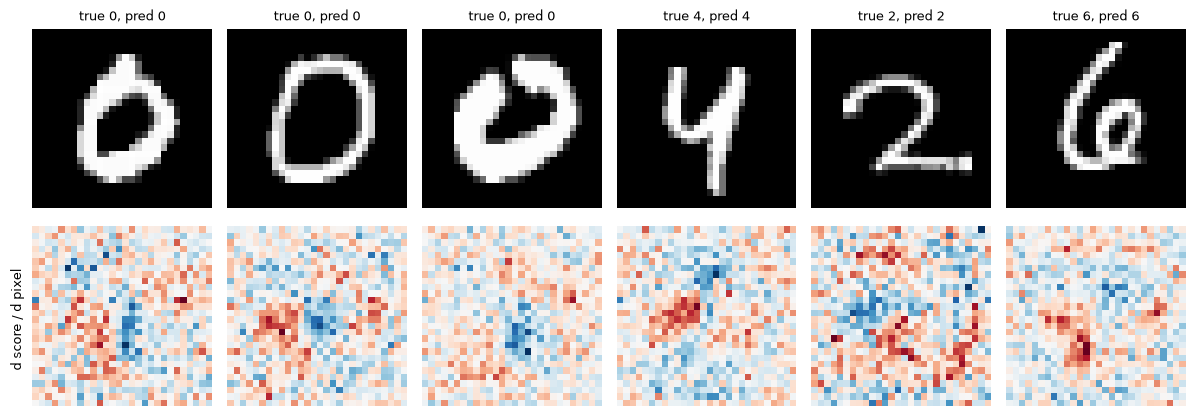

In [34]:
examples = [3, 10, 25, 42, 77, 123]
xb = Xte[examples]
pred = forward(xb, P)[0].argmax(1)

rng = np.random.default_rng(0)
saliency = np.zeros_like(xb)
for _ in range(200):
  xn = xb + 1.0 * rng.standard_normal(xb.shape)     # noisy copy of the images
  logits, cache = forward(xn, P)
  dlogits = np.zeros_like(logits)
  dlogits[np.arange(len(examples)), pred] = 1.0     # gradient of the predicted class score
  saliency += backward(cache, P, dlogits)["X"] / 200

fig, axes = plt.subplots(2, len(examples), figsize=(2 * len(examples), 4.4))
for c in range(len(examples)):
  axes[0, c].imshow(xb[c].reshape(28, 28), cmap='gray')
  axes[0, c].set_title(f'true {Yte[examples[c]]}, pred {pred[c]}', fontsize=9)
  s = saliency[c].reshape(28, 28)
  lim = np.abs(s).max()
  axes[1, c].imshow(s, cmap='RdBu_r', vmin=-lim, vmax=lim)
for ax in axes.ravel(): ax.axis('off')
axes[1, 0].text(-4, 14, 'd score / d pixel', rotation=90, va='center', fontsize=9)
plt.tight_layout()

## 9. Evaluation

Only now do we touch the test set.

In [35]:
for split, (Xs, Ys) in {'train': (Xtr, Ytr), 'val': (Xval, Yval), 'test': (Xte, Yte)}.items():
  l, a = evaluate(Xs, Ys, P)
  print(f'{split:>5}: loss {l:.4f}   accuracy {a*100:.2f}%')

train: loss 0.0106   accuracy 99.89%
  val: loss 0.0881   accuracy 97.67%
 test: loss 0.0905   accuracy 97.48%


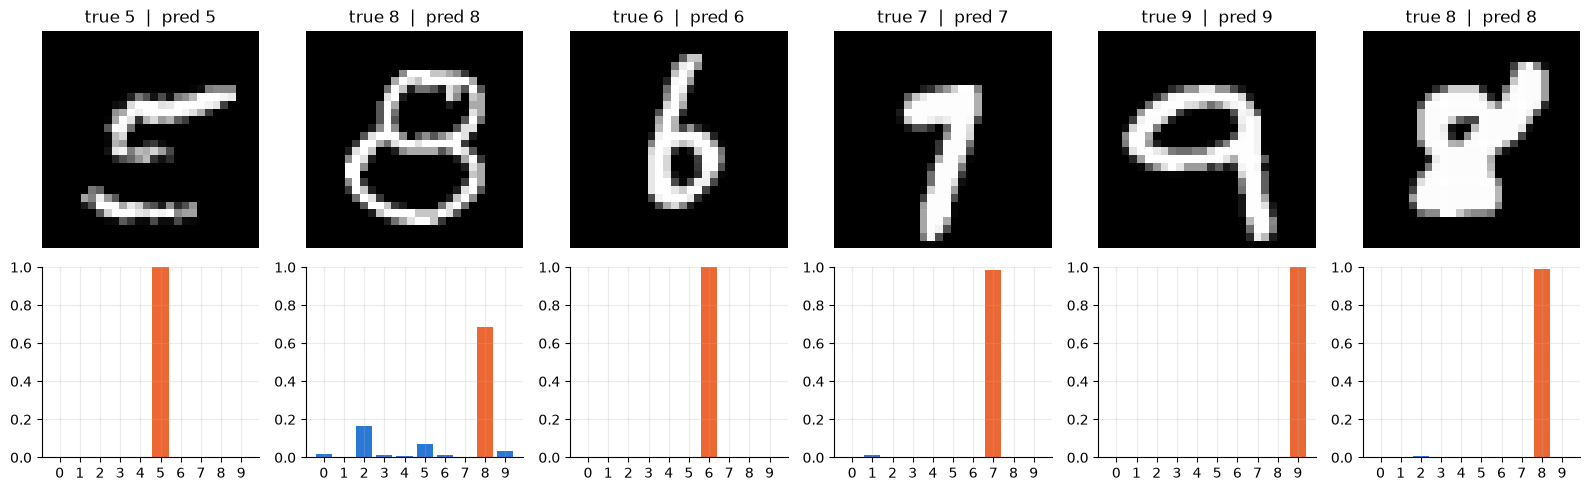

In [36]:
# predictions with the full probability distribution
logits_te, _ = forward(Xte, P)
probs_te = softmax(logits_te)
pred_te = probs_te.argmax(1)

show = np.random.default_rng(3).choice(len(Xte), 6, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(16, 5), gridspec_kw=dict(height_ratios=[1.2, 1]))
for c, i in enumerate(show):
  axes[0, c].imshow(Xte[i].reshape(28, 28), cmap='gray'); axes[0, c].axis('off'); axes[0, c].grid(False)
  axes[0, c].set_title(f'true {Yte[i]}  |  pred {pred_te[i]}', color='black' if pred_te[i] == Yte[i] else ORANGE)
  axes[1, c].bar(range(10), probs_te[i], color=[ORANGE if k == pred_te[i] else BLUE for k in range(10)])
  axes[1, c].set_xticks(range(10)); axes[1, c].set_ylim(0, 1)
plt.tight_layout()

252 mistakes out of 10000 test images


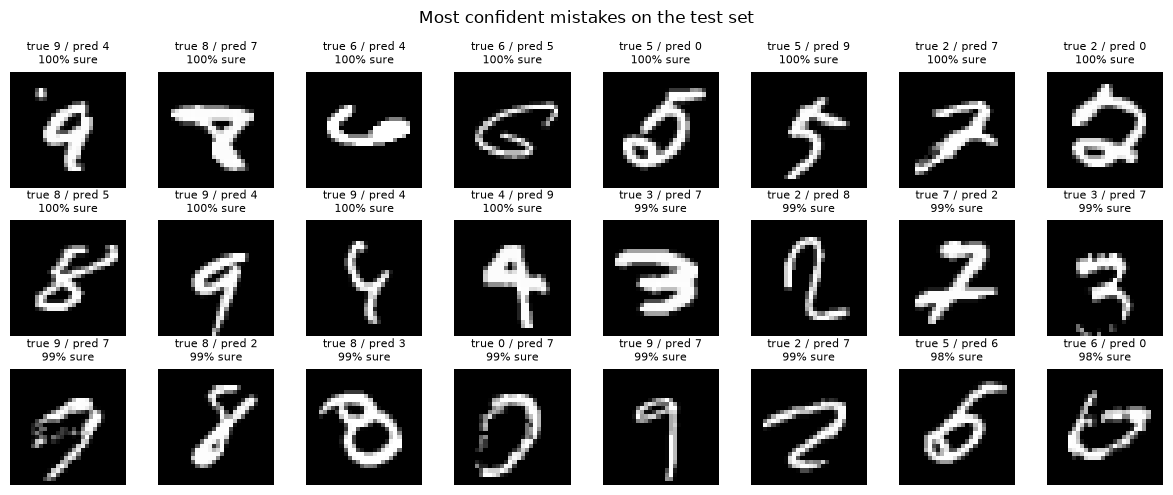

In [37]:
# the mistakes: most of them are genuinely ambiguous handwriting
wrong = np.where(pred_te != Yte)[0]
print(f'{len(wrong)} mistakes out of {len(Yte)} test images')
# sort by how confident the network was in its wrong answer
wrong = wrong[np.argsort(probs_te[wrong, pred_te[wrong]])[::-1]]

fig, axes = plt.subplots(3, 8, figsize=(12, 5))
for ax, i in zip(axes.ravel(), wrong[:24]):
  ax.imshow(Xte[i].reshape(28, 28), cmap='gray'); ax.axis('off'); ax.grid(False)
  ax.set_title(f'true {Yte[i]} / pred {pred_te[i]}\n{probs_te[i, pred_te[i]]*100:.0f}% sure', fontsize=8)
fig.suptitle('Most confident mistakes on the test set')
plt.tight_layout()

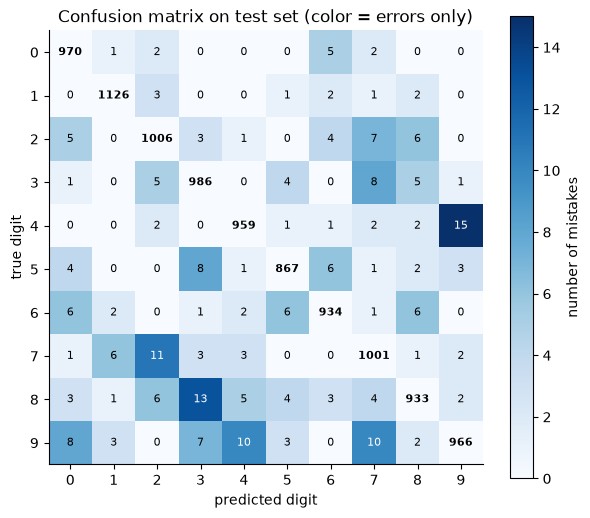

In [38]:
conf = np.zeros((10, 10), dtype=int)
np.add.at(conf, (Yte, pred_te), 1)

fig, ax = plt.subplots(figsize=(7, 6))
ax.grid(False)
off = conf.copy(); np.fill_diagonal(off, 0)     # color only the errors, so they're visible
im = ax.imshow(off, cmap='Blues')
for r in range(10):
  for c in range(10):
    ax.text(c, r, conf[r, c], ha='center', va='center', fontsize=8,
            color='white' if (r != c and off[r, c] > off.max() * 0.6) else 'black',
            fontweight='bold' if r == c else 'normal')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel('predicted digit'); ax.set_ylabel('true digit')
ax.set_title('Confusion matrix on test set (color = errors only)')
plt.colorbar(im, ax=ax, label='number of mistakes');

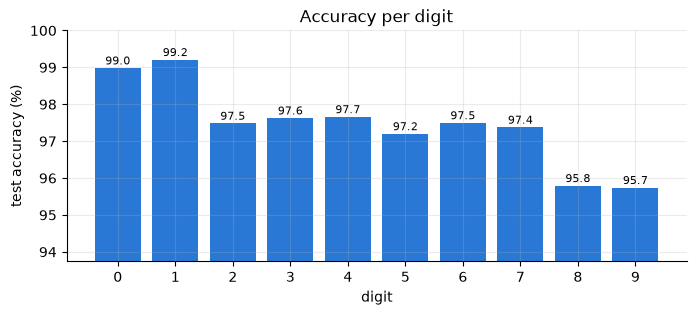

In [39]:
per_class = conf.diagonal() / conf.sum(1)
plt.figure(figsize=(8, 3))
plt.bar(range(10), per_class * 100, color=BLUE)
for k in range(10):
  plt.text(k, per_class[k] * 100 + 0.1, f'{per_class[k]*100:.1f}', ha='center', fontsize=8)
plt.ylim(min(per_class) * 100 - 2, 100)
plt.xticks(range(10)); plt.xlabel('digit'); plt.ylabel('test accuracy (%)')
plt.title('Accuracy per digit');

## Summary

- A neural net layer is just many micrograd neurons at once: `tanh(X @ W + b)`.
- **Know your initial loss**: for 10 classes it should be `-ln(1/10) = 2.303`. If not, fix the init (small output layer, zero output bias).
- **Scale hidden weights by `gain / sqrt(fan_in)`** so `tanh` does not saturate; saturated units have gradient `1 - tanh**2 = 0` and don't learn.
- Backprop by hand is the same chain rule as micrograd; always **gradient check** it.
- Look at the loss on a **log scale** and **smoothed**, and compare train vs validation.
- Watch the **update:data ratio** (about -3) and per-layer gradient sizes to diagnose training.
- First-layer weights, top-activating images, class templates and saliency maps show **what the network sees**.

## Exercises

1. Set the learning rate to `1.0` and to `0.001`. What happens to the loss curve and to the update:data ratio plot?
2. Replace `tanh` with ReLU (`np.maximum(0, z)`, local gradient `z > 0`). What gain should Kaiming init use? Look for dead neurons in the saturation plot (`h == 0`).
3. Train with `n_h1 = 16`. Do the first-layer weight images look different?
4. Remove the L2 term in the linear classifier. What happens to the templates?
5. Train only on digits 1 through 9 (drop the 0s). What should the expected initial loss be now?